# **Intelligent Loan Pricing & Risk Management for Australian Banks**

### **Author**
Pranamya Rajbhandari

### **Goal**
The goal of this project is to develop an end-to-end credit risk management system for Australian banks that:

1. Predicts default probability using applicant data (income, employment, credit history, loan amount, etc.)
2. Optimizes loan pricing by converting default risk into risk-based interest rates
3. Detects early delinquency signals to identify at-risk borrowers within 6 months of approval
4. Segments customers into risk tiers (Prime/Near-Prime/Subprime/High-Risk) with tailored approval strategies
5. Calculates expected loss and portfolio profitability by risk tier

### **Australian Context**
Features engineered specifically for Australian lending patterns (employment stability, housing burden ratios, regional economics). Compliance with ASIC, Privacy Act, and RBA risk management standards.

### **Technologies and Tools Used**
* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Imbalanced-learn (SMOTE)
* Streamlit
* Jupyter Notebook

## **1. Introduction**

Credit risk modeling in banking has two critical purposes:

1. **Approval Decision**: Should we approve this loan?
2. **Pricing Decision**: If approved, what interest rate minimizes expected loss?

This project implements risk-based pricing—converting default probability into optimal interest rates that approve more customers while pricing risk appropriately and maximizing portfolio profitability.

Additionally, an early warning system identifies borrowers showing delinquency signals within 6 months, enabling proactive intervention before defaults occur.

### **Key Components**

**1. Default Prediction Model**
Classification models (Logistic Regression, Random Forest, Gradient Boosting) with SMOTE for imbalanced data handling. Output: Default probability (0-100%).

**2. Risk-Based Pricing Strategy**
Expected Loss = Default Probability × Loss Given Default
Risk Premium = (Expected Loss / Loan Amount) in basis points
Suggested Rate = Base Rate + Risk Premium

**3. Early Warning System**
Time-series features tracking payment degradation and credit utilization trends. Identifies customers likely to miss payments within 6 months.

**4. Portfolio Analysis**
Profitability by risk tier, expected loss by segment, optimal portfolio composition.

### **Data Overview**

Dataset: Aussie Bank Loan Approval Dataset (610 records)

Variables: Loan ID, Gender, Marital Status, Education Level, Income, Loan Amount, Location, Credit History, Approval Status (target).

### **Methodology**

1. Exploratory Data Analysis - Data quality, missing values, class distribution
2. Feature Engineering - Australian-specific indicators (employment, debt ratios, regional risk)
3. Model Development - Train/test split, SMOTE, cross-validation
4. Default Risk Quantification - Probability calibration, ROC-AUC analysis
5. Pricing & Segmentation - Expected loss calculations, risk-based pricing, customer tier assignment
6. Early Warning System - Delinquency prediction and intervention recommendations
7. Deployment - Streamlit interactive dashboard and pricing calculator

### **Expected Outcomes**

Default prediction accuracy of 80%+, clear risk-to-price mapping, profitable pricing strategy, and early identification of at-risk borrowers.

## **2. Import Python Libraries**


In [108]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn as sk
import imblearn as imb
import shap
import fairlearn as fl

## **3. Load Dataset**
Display:
* Dataset Shape
* First Five Rows (.head())
* Data Types
* Rename Columns

In [109]:
df = pd.read_csv(r'C:\Users\prana\OneDrive\Desktop\DS_proj_credit_risk\Intelligent Loan Pricing ML Project\dataset\focused_synthetic_loan_data.csv')
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,DebtToIncomeRatio,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-03,45,68809,546,Employed,Associate,24,22777,48,Married,...,0.674404,10,25088,0.200508,0.204600,698.706646,0.069223,0.191053,1,40.0
1,2018-01-04,38,15000,575,Employed,High School,16,10155,12,Married,...,0.860514,3,45270,0.173806,0.169819,926.096927,0.123102,0.863387,0,56.0
2,2018-01-05,47,137921,522,Employed,Doctorate,26,263359,360,Divorced,...,0.889217,3,5285,0.317120,0.250000,5489.925450,0.044195,0.521812,0,52.0
3,2018-01-06,58,39656,553,Employed,Bachelor,36,41676,24,Single,...,0.607728,5,228590,0.189159,0.205910,2133.185876,0.075930,0.721242,0,47.0
4,2018-01-09,37,82748,416,Employed,Bachelor,18,15629,24,Single,...,0.943965,5,4648,0.257414,0.248252,832.773241,0.072499,0.193249,1,38.4


In [110]:
df.shape

(2000, 36)

In [111]:
import re

# Convert camelCase headers to readable names with spaces
# Example: ApplicationDate -> Application Date
#          RiskScore -> Risk Score
df.columns = [re.sub(r'(?<!^)(?=[A-Z])', ' ', col) for col in df.columns]
df.head()

,Application Date,Age,Annual Income,Credit Score,Employment Status,Education Level,Experience,Loan Amount,Loan Duration,Marital Status,...,Utility Bills Payment History,Job Tenure,Net Worth,Base Interest Rate,Interest Rate,Monthly Loan Payment,Debt To Income Ratio,Total Debt To Income Ratio,Loan Approved,Risk Score
0,2018-01-03,45,68809,546,Employed,Associate,24,22777,48,Married,...,0.674404,10,25088,0.200508,0.204600,698.706646,0.069223,0.191053,1,40.0
1,2018-01-04,38,15000,575,Employed,High School,16,10155,12,Married,...,0.860514,3,45270,0.173806,0.169819,926.096927,0.123102,0.863387,0,56.0
2,2018-01-05,47,137921,522,Employed,Doctorate,26,263359,360,Divorced,...,0.889217,3,5285,0.317120,0.250000,5489.925450,0.044195,0.521812,0,52.0
3,2018-01-06,58,39656,553,Employed,Bachelor,36,41676,24,Single,...,0.607728,5,228590,0.189159,0.205910,2133.185876,0.075930,0.721242,0,47.0
4,2018-01-09,37,82748,416,Employed,Bachelor,18,15629,24,Single,...,0.943965,5,4648,0.257414,0.248252,832.773241,0.072499,0.193249,1,38.4


In [112]:
df.dtypes

Application Date                     str
Age                                int64
Annual Income                      int64
Credit Score                       int64
Employment Status                    str
Education Level                      str
Experience                         int64
Loan Amount                        int64
Loan Duration                      int64
Marital Status                       str
Number Of Dependents               int64
Home Ownership Status                str
Monthly Debt Payments              int64
Credit Card Utilization Rate     float64
Number Of Open Credit Lines        int64
Number Of Credit Inquiries         int64
Bankruptcy History                 int64
Loan Purpose                         str
Previous Loan Defaults             int64
Payment History                    int64
Length Of Credit History           int64
Savings Account Balance            int64
Checking Account Balance           int64
Total Assets                       int64
Total Liabilitie

## **4. Data Observation and Data Cleaning**
**Overview**

The dataset was examined to understand its structure, data types, summary statistics, and any missing values. Numerical and categorical features were identified for furthering preprocessing.

**Data Cleaning**
Preprocessing: 
* Checked dataset shape and feature information
* Analysed summary statistics and missing values
* Imputed missing value (none found in dataset: checked with .isna() and .isnull())
* Checked and removed duplicate records if found
* Verified data quality before model training

**Observation**
* The dataset contained both numerical and categorical features
* Missing values were successfully handled using median and mode imputation
* No significant data quality issues remained after preprocessing
* The cleaned dataset was ready for exploratory analysis and model development

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Application Date               2000 non-null   str    
 1   Age                            2000 non-null   int64  
 2   Annual Income                  2000 non-null   int64  
 3   Credit Score                   2000 non-null   int64  
 4   Employment Status              2000 non-null   str    
 5   Education Level                2000 non-null   str    
 6   Experience                     2000 non-null   int64  
 7   Loan Amount                    2000 non-null   int64  
 8   Loan Duration                  2000 non-null   int64  
 9   Marital Status                 2000 non-null   str    
 10  Number Of Dependents           2000 non-null   int64  
 11  Home Ownership Status          2000 non-null   str    
 12  Monthly Debt Payments          2000 non-null   int64  
 13 

**Observations on Key Attributes: Age, Annual Income, Credit Score, Employment Status, Loan Amount**

In [114]:
df["Age"].unique()

array([45, 38, 47, 58, 37, 49, 34, 46, 42, 18, 19, 33, 27, 43, 29, 23, 57,
       40, 22, 41, 26, 44, 32, 36, 62, 39, 25, 24, 48, 31, 52, 35, 51, 56,
       30, 50, 69, 53, 66, 28, 21, 55, 20, 72, 80, 67, 65, 61, 59, 54, 64,
       63, 76, 60, 70, 71, 68, 78, 77])

In [115]:
df["Annual Income"].describe()

count      2000.000000
mean      57501.834000
std       42777.222696
min        1034.000000
25%       29513.500000
50%       46480.000000
75%       72487.250000
max      300000.000000
Name: Annual Income, dtype: float64

In [116]:
df["Credit Score"].describe()

count    2000.000000
mean      572.026000
std        49.669577
min       396.000000
25%       541.000000
50%       579.000000
75%       607.000000
max       696.000000
Name: Credit Score, dtype: float64

In [117]:
df["Employment Status"].unique()

<ArrowStringArray>
['Employed', 'Self-Employed', 'Unemployed']
Length: 3, dtype: str

In [118]:
df["Loan Amount"].describe()

count      2000.000000
mean      65454.100500
std       79602.420402
min        1423.000000
25%       14582.500000
50%       23553.000000
75%      112755.000000
max      545047.000000
Name: Loan Amount, dtype: float64

In [119]:
df.describe()

,Age,Annual Income,Credit Score,Experience,Loan Amount,Loan Duration,Number Of Dependents,Monthly Debt Payments,Credit Card Utilization Rate,Number Of Open Credit Lines,...,Utility Bills Payment History,Job Tenure,Net Worth,Base Interest Rate,Interest Rate,Monthly Loan Payment,Debt To Income Ratio,Total Debt To Income Ratio,Loan Approved,Risk Score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,40.183000,57501.834000,572.026000,17.931000,65454.100500,117.612000,1.540500,453.860500,0.277492,3.017500,...,0.799821,4.949500,7.733340e+04,0.210794,0.203045,1534.553281,0.111407,0.560736,0.339500,47.005800
std,11.526532,42777.222696,49.669577,11.316062,79602.420402,115.127115,1.378154,397.444479,0.157381,1.700482,...,0.122484,2.167556,1.360255e+05,0.045610,0.036833,1519.660707,0.104034,0.546870,0.473658,7.657156
min,18.000000,1034.000000,396.000000,0.000000,1423.000000,12.000000,0.000000,35.000000,0.001224,0.000000,...,0.214633,0.000000,1.017000e+03,0.118272,0.101647,69.649452,0.017337,0.053993,0.000000,27.200000
25%,32.000000,29513.500000,541.000000,9.750000,14582.500000,36.000000,0.000000,200.000000,0.156996,2.000000,...,0.724407,3.000000,8.517000e+03,0.175421,0.172606,504.206081,0.062006,0.213116,0.000000,40.000000
50%,40.000000,46480.000000,579.000000,17.000000,23553.000000,60.000000,1.000000,332.000000,0.252188,3.000000,...,0.820882,5.000000,3.133550e+04,0.200732,0.202156,808.951119,0.088683,0.348815,0.000000,48.000000
75%,48.000000,72487.250000,607.000000,26.000000,112755.000000,240.000000,3.000000,564.250000,0.375493,4.000000,...,0.894705,6.000000,9.169525e+04,0.241623,0.243934,2344.275655,0.129528,0.710677,1.000000,52.000000
max,80.000000,300000.000000,696.000000,58.000000,545047.000000,360.000000,5.000000,4105.000000,0.802016,11.000000,...,0.998146,14.000000,1.877838e+06,0.355273,0.250000,11361.933318,2.000000,3.000000,1.000000,75.000000


**Check Duplicates**

In [120]:
df.duplicated().sum()

np.int64(0)

**Check for missing values & NULL in the dataset**

In [121]:
df.isnull().sum()

Application Date                 0
Age                              0
Annual Income                    0
Credit Score                     0
Employment Status                0
Education Level                  0
Experience                       0
Loan Amount                      0
Loan Duration                    0
Marital Status                   0
Number Of Dependents             0
Home Ownership Status            0
Monthly Debt Payments            0
Credit Card Utilization Rate     0
Number Of Open Credit Lines      0
Number Of Credit Inquiries       0
Bankruptcy History               0
Loan Purpose                     0
Previous Loan Defaults           0
Payment History                  0
Length Of Credit History         0
Savings Account Balance          0
Checking Account Balance         0
Total Assets                     0
Total Liabilities                0
Monthly Income                   0
Utility Bills Payment History    0
Job Tenure                       0
Net Worth           

In [122]:
df.isna().sum()

Application Date                 0
Age                              0
Annual Income                    0
Credit Score                     0
Employment Status                0
Education Level                  0
Experience                       0
Loan Amount                      0
Loan Duration                    0
Marital Status                   0
Number Of Dependents             0
Home Ownership Status            0
Monthly Debt Payments            0
Credit Card Utilization Rate     0
Number Of Open Credit Lines      0
Number Of Credit Inquiries       0
Bankruptcy History               0
Loan Purpose                     0
Previous Loan Defaults           0
Payment History                  0
Length Of Credit History         0
Savings Account Balance          0
Checking Account Balance         0
Total Assets                     0
Total Liabilities                0
Monthly Income                   0
Utility Bills Payment History    0
Job Tenure                       0
Net Worth           

**Further Observation**

In [123]:
df["Loan Purpose"].value_counts()

Loan Purpose
Home                  607
Debt Consolidation    503
Auto                  404
Education             296
Other                 190
Name: count, dtype: int64

In [124]:
df["Loan Approved"].value_counts()

Loan Approved
0    1321
1     679
Name: count, dtype: int64

In [125]:
df["Interest Rate"].unique()

array([0.20459977, 0.16981878, 0.25      , ..., 0.20594209, 0.2395764 ,
       0.15254086], shape=(1562,))

In [126]:
df["Education Level"].value_counts()    

Education Level
High School    611
Bachelor       563
Associate      417
Master         305
Doctorate      104
Name: count, dtype: int64

## **5. Exploratory Data Analysis (EDA)**




Exploratory data analysis involves exploring underlying structures, patterns, relationships, and outliers within the data before formal modeling can commence.

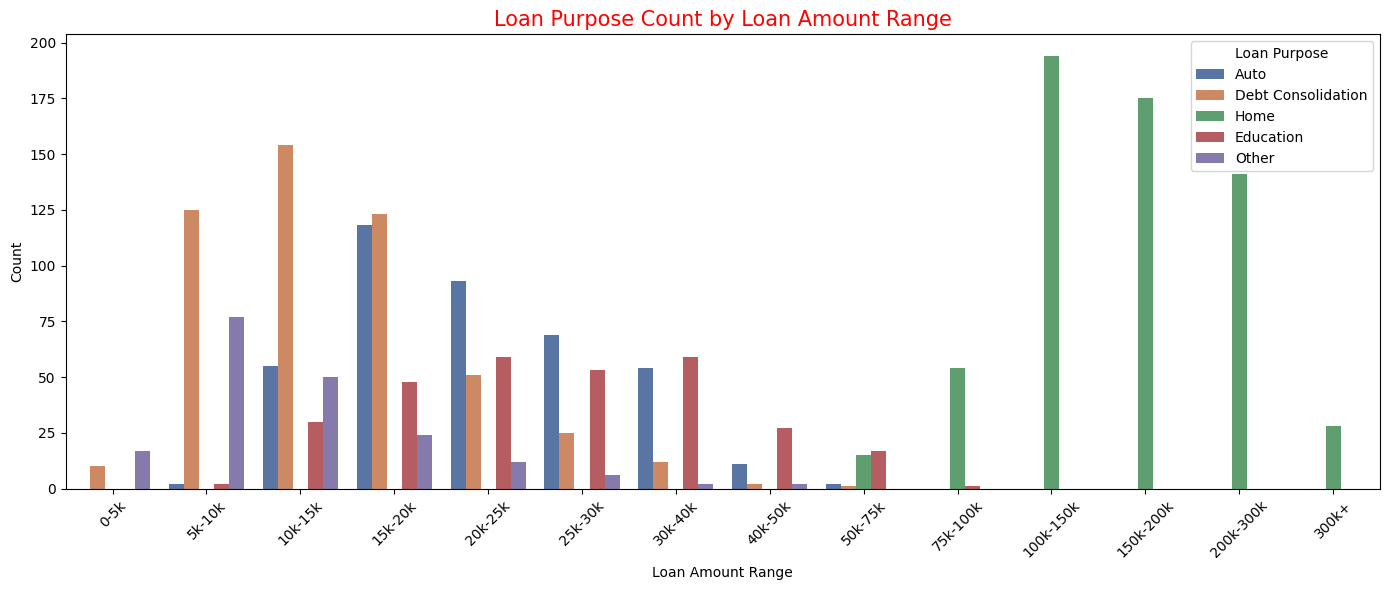

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Create loan amount ranges (bins) — widened to account for Home loans now
# realistically reaching into the $100k-$500k+ range
bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, 40000, 50000,
        75000, 100000, 150000, 200000, 300000, df['Loan Amount'].max()]
labels = ['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k-25k',
          '25k-30k', '30k-40k', '40k-50k', '50k-75k',
          '75k-100k', '100k-150k', '150k-200k', '200k-300k', '300k+']

df['LoanAmountRange'] = pd.cut(df['Loan Amount'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(14,6))
ax = sns.countplot(data=df, x='LoanAmountRange', hue='Loan Purpose', palette='deep')

plt.title("Loan Purpose Count by Loan Amount Range", color='red', fontsize=15)
plt.xlabel("Loan Amount Range")
plt.ylabel("Count")
plt.xticks(rotation=45)

ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

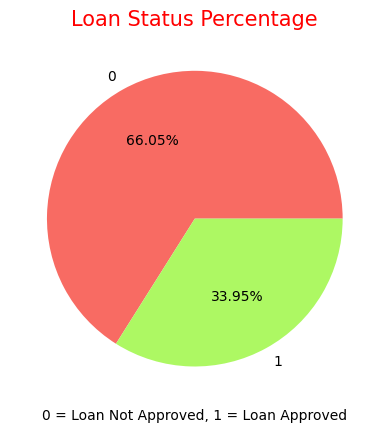

In [128]:
plt.pie(df['Loan Approved'].value_counts(),labels=df['Loan Approved'].value_counts().index,autopct='%1.2f%%',colors=["#F86B63","#ADF863"])
plt.title("Loan Status Percentage",color='red',fontsize=15)
plt.xlabel("0 = Loan Not Approved, 1 = Loan Approved")
plt.show()

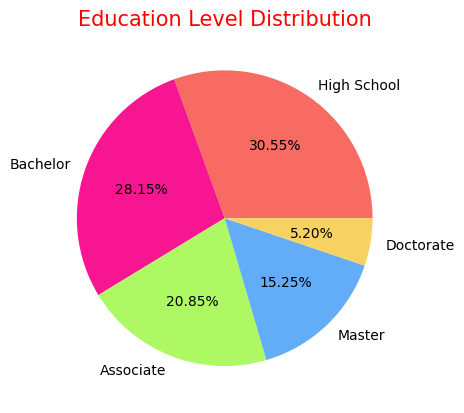

In [129]:
plt.pie(df['Education Level'].value_counts(),labels=df['Education Level'].value_counts().index,autopct='%1.2f%%',colors=["#F86B63","#F81592","#ADF863","#63ADF8","#F8D163"])
plt.title("Education Level Distribution", color='red', fontsize=15)
plt.show()

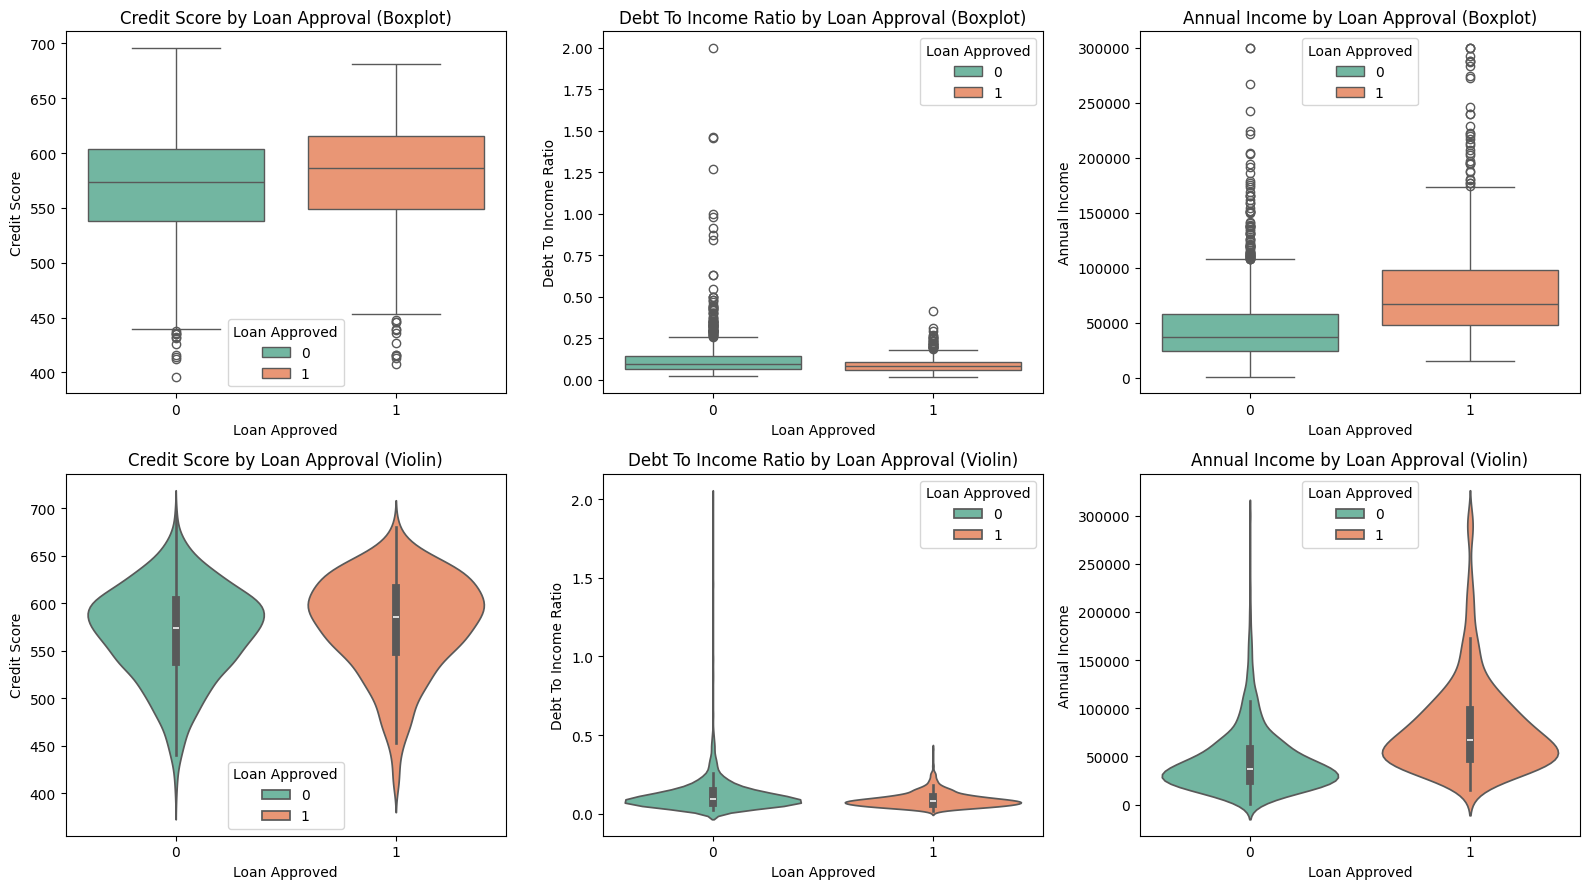

In [130]:
# Set up figure with 3 columns (one per variable)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

variables = ['Credit Score', 'Debt To Income Ratio', 'Annual Income']

# Row 1: Boxplots
for i, var in enumerate(variables):
    sns.boxplot(data=df, x='Loan Approved', y=var, ax=axes[0, i], hue = 'Loan Approved', palette='Set2')
    axes[0, i].set_title(f'{var} by Loan Approval (Boxplot)')
    axes[0, i].set_xlabel('Loan Approved')

# Row 2: Violin plots
for i, var in enumerate(variables):
    sns.violinplot(data=df, x='Loan Approved', y=var, ax=axes[1, i], hue = 'Loan Approved', palette='Set2')
    axes[1, i].set_title(f'{var} by Loan Approval (Violin)')
    axes[1, i].set_xlabel('Loan Approved')

plt.tight_layout()
plt.show()

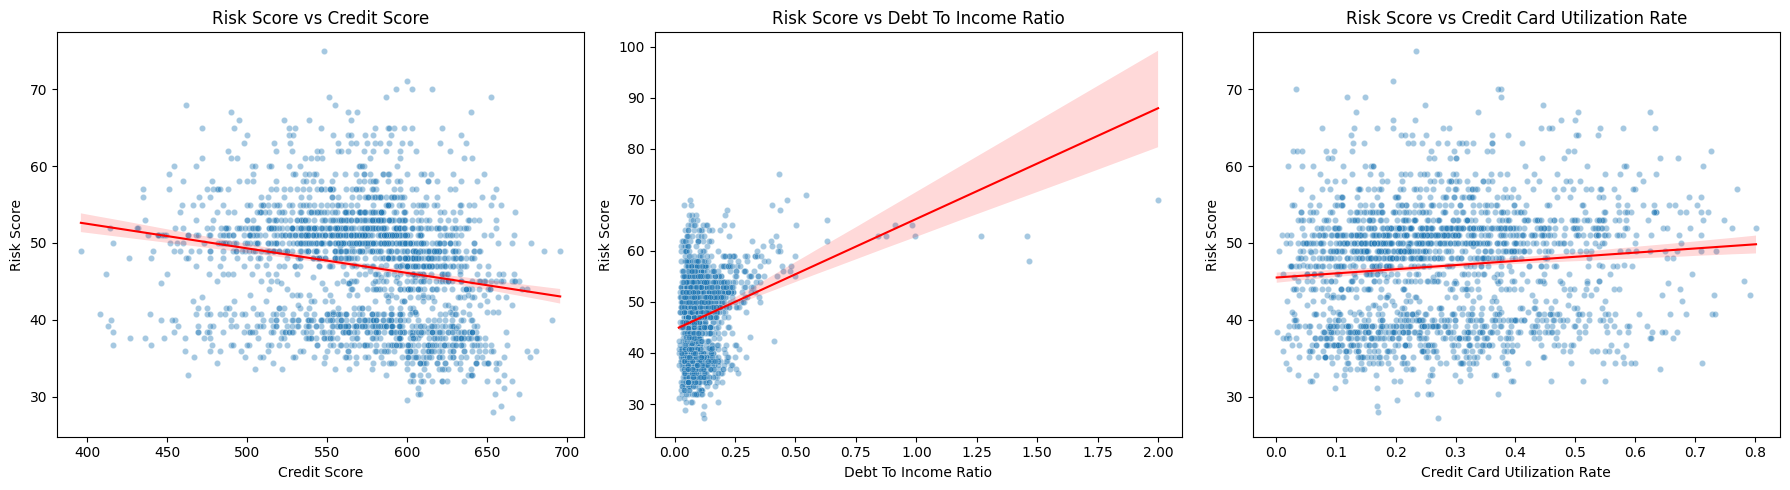

In [131]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = ['Credit Score', 'Debt To Income Ratio', 'Credit Card Utilization Rate']

for i, var in enumerate(variables):
    sns.scatterplot(
        data=df, x=var, y='Risk Score',
        alpha=0.4, s=20, ax=axes[i]
    )
    # add a regression trendline to make the relationship easier to read
    sns.regplot(
        data=df, x=var, y='Risk Score',
        scatter=False, ax=axes[i], color='red', line_kws={'linewidth': 1.5}
    )
    axes[i].set_title(f'Risk Score vs {var}')

plt.tight_layout()
plt.show()

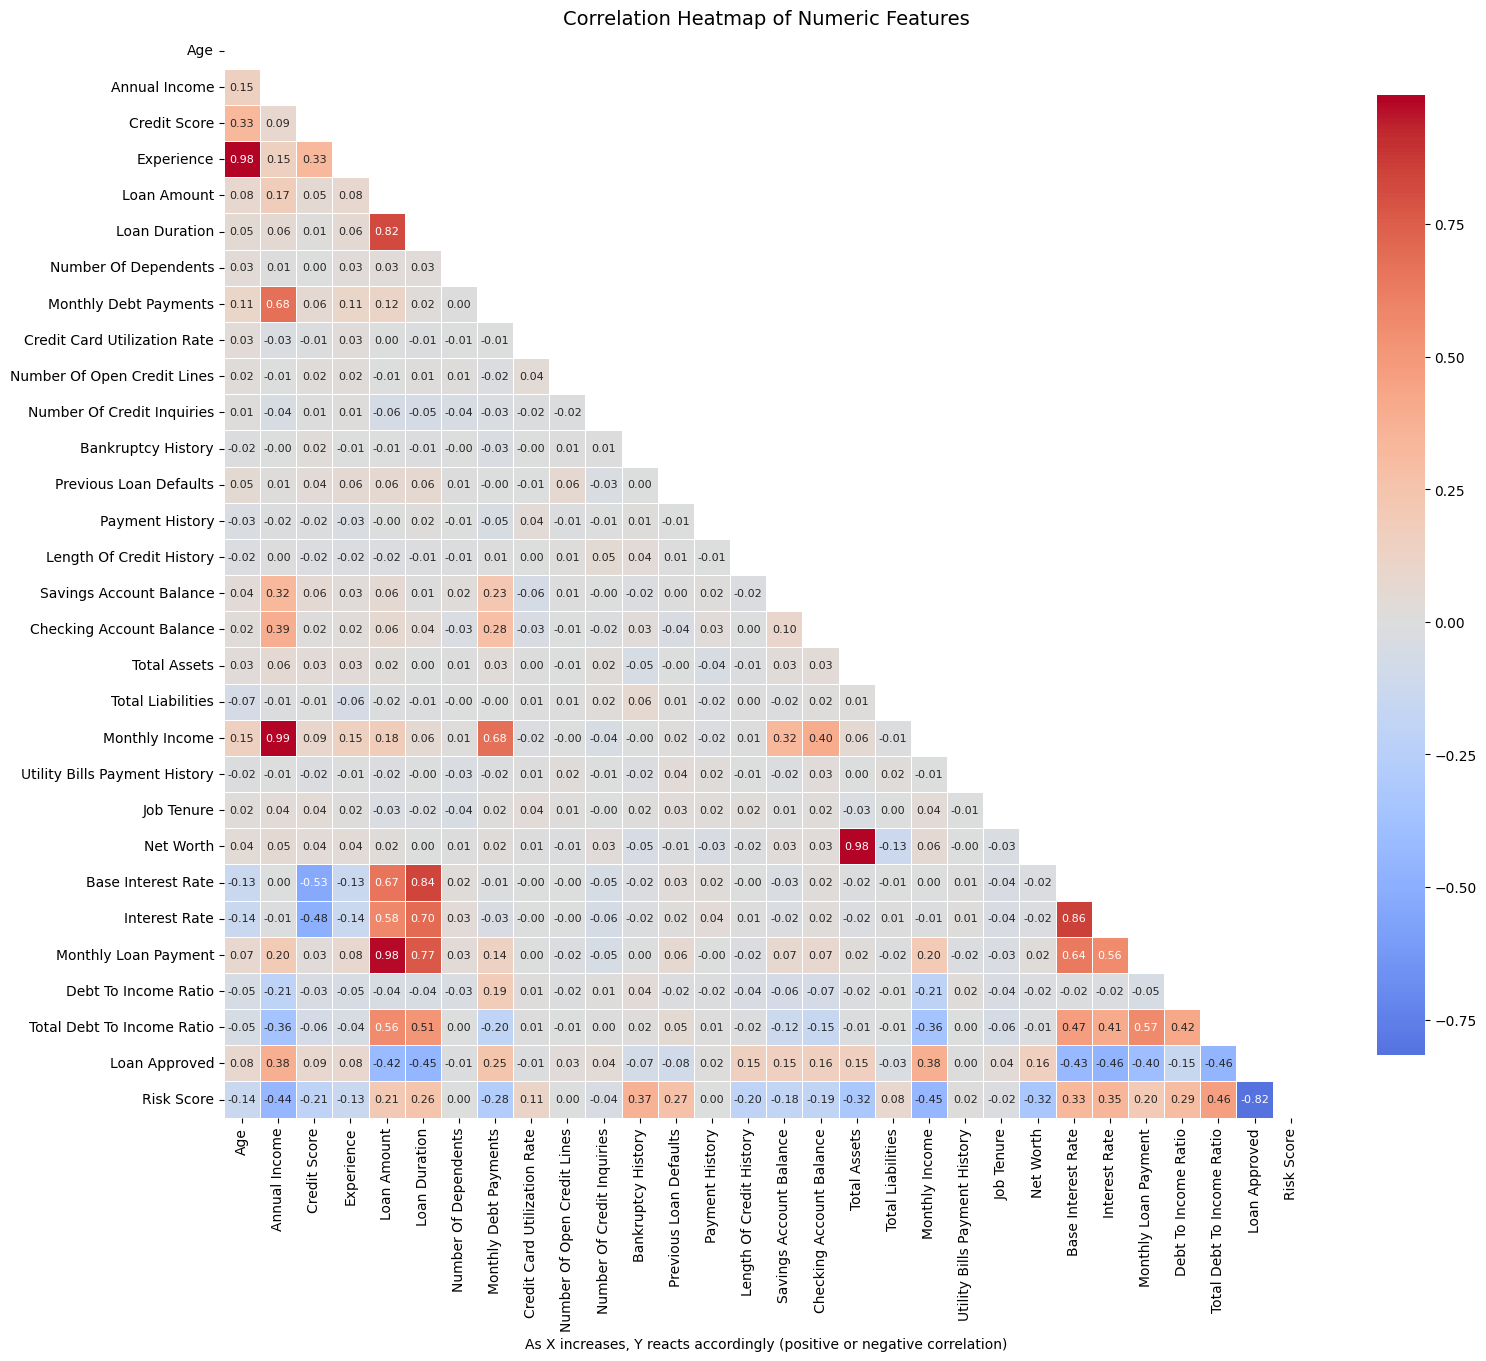

In [132]:
# Select only numeric columns (drops ApplicationDate, EmploymentStatus, etc.)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Mask the upper triangle so you're not reading duplicate info
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.xlabel("As X increases, Y reacts accordingly (positive or negative correlation)")
plt.show()

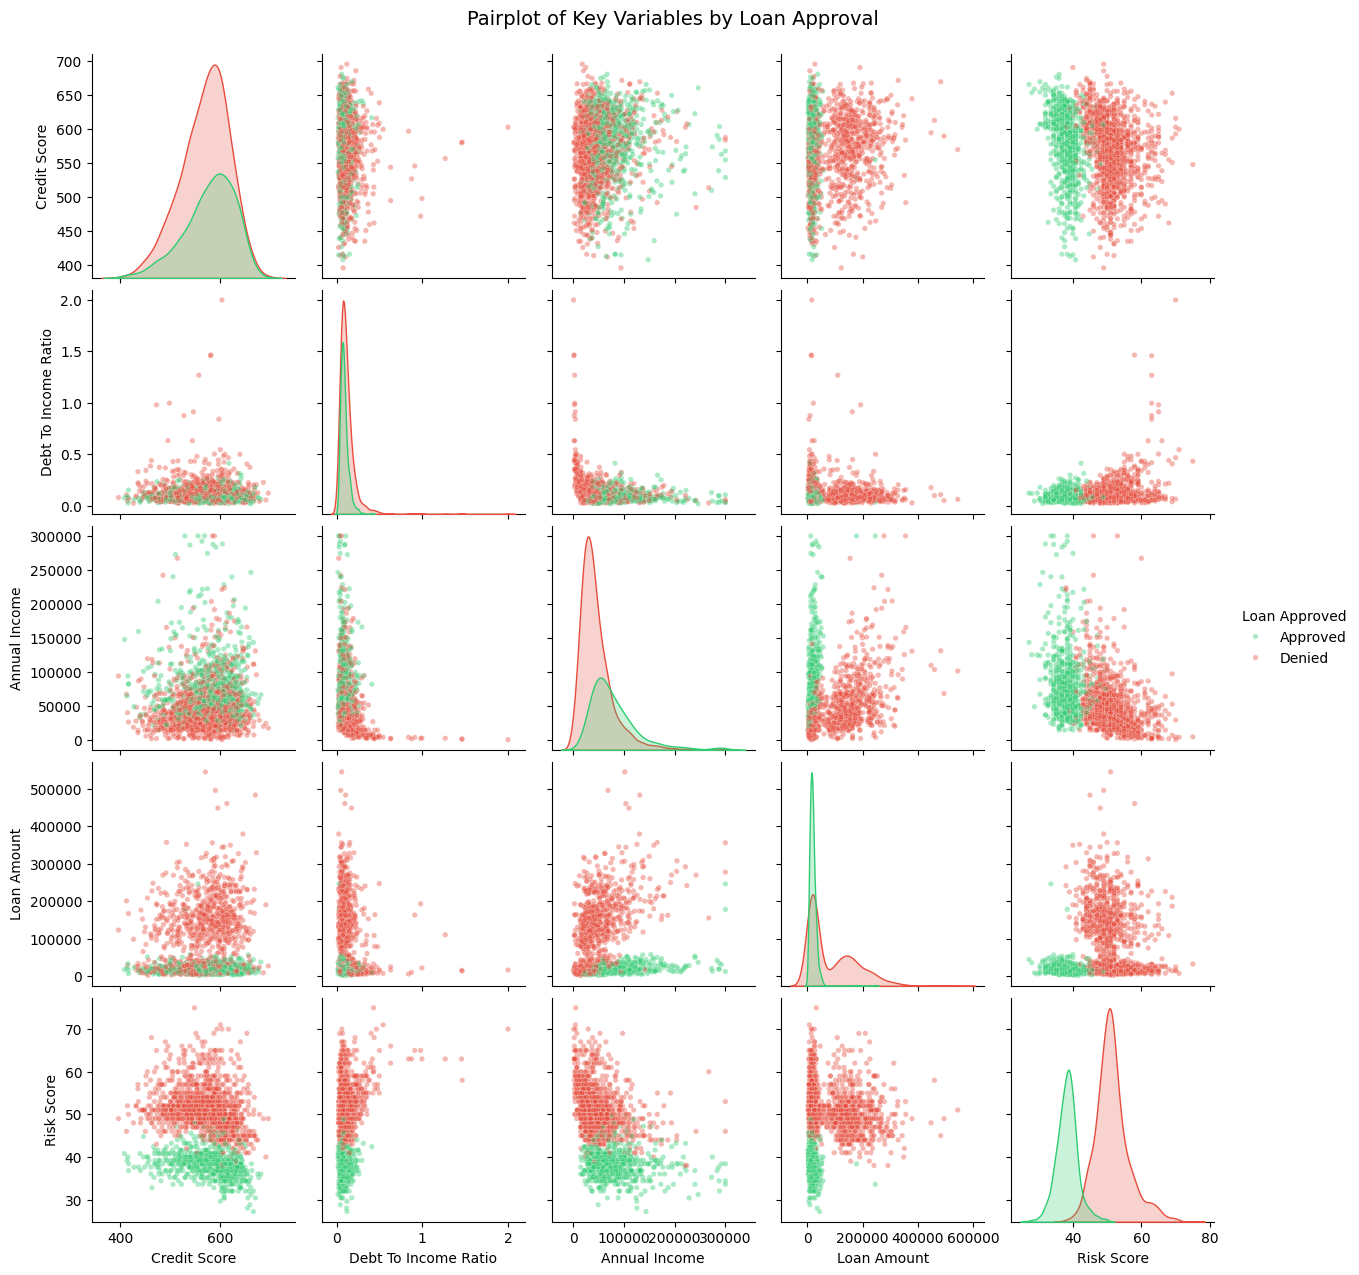

In [133]:
# Map LoanApproved to readable labels for the legend
df['Loan Approved'] = df['Loan Approved'].map({0: 'Denied', 1: 'Approved'})

variables = ['Credit Score', 'Debt To Income Ratio', 'Annual Income', 'Loan Amount', 'Risk Score']

g = sns.pairplot(
    df,
    vars=variables,
    hue='Loan Approved',
    palette={'Approved': '#2ecc71', 'Denied': '#e74c3c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    height=2.5
)

g.fig.suptitle('Pairplot of Key Variables by Loan Approval', y=1.02, fontsize=14)
plt.show()

## **6. Feature Engineering**

Selecting, Manipulating, and tranforming the raw data into features (inputs) to improve performance and accuracy for machine learning models.